In [4]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.rnn as rnn_utils


class SelfAttention(nn.Module):
    def __init__(self, hidden_size):
        super(SelfAttention, self).__init__()
        self.hidden_size = hidden_size
        self.attn = nn.Linear(hidden_size * 2, hidden_size)  # 
        self.v = nn.Parameter(torch.rand(hidden_size)) # 
        
    def forward(self, hidden_states, mask=None):
        """
        hidden_states: [batch_size, seq_len, hidden_size * 2]
        mask: [batch_size, seq_len] - zero-padding mask
        """
        attn_weights = torch.tanh(self.attn(hidden_states))  # [batch_size, seq_len, hidden_size]
        attn_weights = attn_weights.matmul(self.v)           # [batch_size, seq_len]
        attn_weights = F.softmax(attn_weights, dim=1)        # [batch_size, seq_len]에서 softmax로 중요도 결정
        
        context = torch.sum(hidden_states * attn_weights.unsqueeze(-1), dim=1)  # [batch_size, hidden_size * 2]
        return context, attn_weights

class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=0.3)
        self.attention = SelfAttention(hidden_size)
        self.fc = nn.Linear(hidden_size * 2, num_classes)  
        self.dropout = nn.Dropout(0.5)

    def forward(self, x, lengths, lstm_outputs=False):
        batch_size, seq_len, _ = x.size()

        h0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size, device=x.device)
        
        packed_x = rnn_utils.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        self.lstm.flatten_parameters()
        packed_out, (hn, cn) = self.lstm(packed_x, (h0, c0))

        out, _ = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)
        mask = torch.arange(seq_len).expand(batch_size, seq_len).to(x.device) < lengths.unsqueeze(1).to(x.device)
        
        context, attn_weights = self.attention(out, mask) 
        
        out_last = self.dropout(context) 
        out_fc = self.fc(out_last) 
                
        if lstm_outputs:
            return out_fc, out, attn_weights
        else:
            return out_fc

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.rnn as rnn_utils

class CrossAttention(nn.Module):
    def __init__(self, hidden_size, reduction_ratio=2, dropout=0.1):
        super(CrossAttention, self).__init__()
        self.hidden_size = hidden_size
        self.reduced_size = hidden_size // reduction_ratio  # Low-rank Approximation

        self.query = nn.Linear(hidden_size, self.reduced_size)  # [hidden_size -> reduced_size]
        self.key = nn.Linear(hidden_size * 2, self.reduced_size)  # [hidden_size * 2 -> reduced_size]
        self.value = nn.Linear(hidden_size * 2, self.reduced_size)  # [hidden_size * 2 -> reduced_size]
        self.out = nn.Linear(self.reduced_size, hidden_size)  # [reduced_size -> hidden_size]
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, mask=None):
        """
        queries: [batch_size, target_len, hidden_size]
        keys: [batch_size, source_len, hidden_size * 2]
        values: [batch_size, source_len, hidden_size * 2]
        mask: [batch_size, source_len]
        """
        # Transform Query
        query_proj = self.query(queries)  # [batch_size, target_len, reduced_size]

        # Flatten keys and values for Linear transformation
        batch_size, source_len, _ = keys.size()
        keys_flat = keys.view(-1, keys.size(-1))  # [batch_size * source_len, hidden_size * 2]
        values_flat = values.view(-1, values.size(-1))  # [batch_size * source_len, hidden_size * 2]

        # Transform Key and Value
        key_proj_flat = self.key(keys_flat)  # [batch_size * source_len, reduced_size]
        value_proj_flat = self.value(values_flat)  # [batch_size * source_len, reduced_size]

        # Reshape back to original dimensions
        key_proj = key_proj_flat.view(batch_size, source_len, -1)  # [batch_size, source_len, reduced_size]
        value_proj = value_proj_flat.view(batch_size, source_len, -1)  # [batch_size, source_len, reduced_size]

        # Compute attention scores
        attn_scores = torch.bmm(query_proj, key_proj.transpose(1, 2))  # [batch_size, target_len, source_len]

        
        if mask is not None:
            mask = mask.unsqueeze(1).expand(-1, attn_scores.size(1), -1)  # [batch_size, target_len, source_len]
            print(f"attn_scores shape: {attn_scores.shape}")  # Expected: [batch_size, target_len, source_len]
            print(f"mask shape: {mask.shape}")  # Expected: [batch_size, target_len, source_len]

            attn_scores = attn_scores.masked_fill(mask == 0, float('-inf'))

        # Normalize attention scores
        attn_weights = F.softmax(attn_scores, dim=-1)  # [batch_size, target_len, source_len]

        # Compute context vectors
        context = torch.bmm(attn_weights, value_proj)  # [batch_size, target_len, reduced_size]
        context = self.out(context)  # [batch_size, target_len, hidden_size]

        return context, attn_weights

class BiLSTM_CA(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, query_len, dropout=0.1):
        super(BiLSTM_CA, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.query_len = query_len

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True, dropout=dropout)
        self.attention = CrossAttention(hidden_size, reduction_ratio=2, dropout=dropout)
        self.query = nn.Parameter(torch.randn(1, query_len, hidden_size))  # Learnable Query
        self.key_transform = nn.Linear(hidden_size * 2, hidden_size)  # Reduce from hidden_size * 2 to hidden_size
        self.value_transform = nn.Linear(hidden_size * 2, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)  # Classification layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths, lstm_outputs=False):
        batch_size, seq_len, _ = x.size()

        # Initialize LSTM hidden states
        h0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size, device=x.device)

        # Pack and process LSTM output
        packed_x = rnn_utils.pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        self.lstm.flatten_parameters()
        packed_out, _ = self.lstm(packed_x, (h0, c0))
        out, _ = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)  # [batch_size, seq_len, hidden_size * 2]

        # Create mask for padding
        mask = torch.arange(seq_len).expand(batch_size, seq_len).to(x.device) < lengths.unsqueeze(1).to(x.device)

        # Transform BiLSTM output to match Cross-Attention
        keys = out  # [batch_size, seq_len, hidden_size * 2]
        values = out  # [batch_size, seq_len, hidden_size * 2]
        queries = self.query.expand(batch_size, -1, -1)  # [batch_size, query_len, hidden_size]

        # Cross-Attention
        context, attn_weights = self.attention(queries, keys, values, mask)

        # Final classification
        out_last = self.dropout(context[:, -1, :])  # Use the last query result
        out_fc = self.fc(out_last)  # [batch_size, num_classes]

        if lstm_outputs:
            return out_fc, out, attn_weights
        else:
            return out_fc


Epoch 1/500:   0%|          | 0/432 [00:00<?, ?it/s]/home/kiwan/anaconda3/lib/python3.11/site-packages/scipy/signal/_spectral_py.py:1870: UserWarning: Input data is complex, switching to return_onesided=False
  warnings.warn('Input data is complex, switching to '
/home/kiwan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kiwan/anaconda3/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
Epoch 1/500:   0%|          | 0/432 [00:00<?, ?it/s]


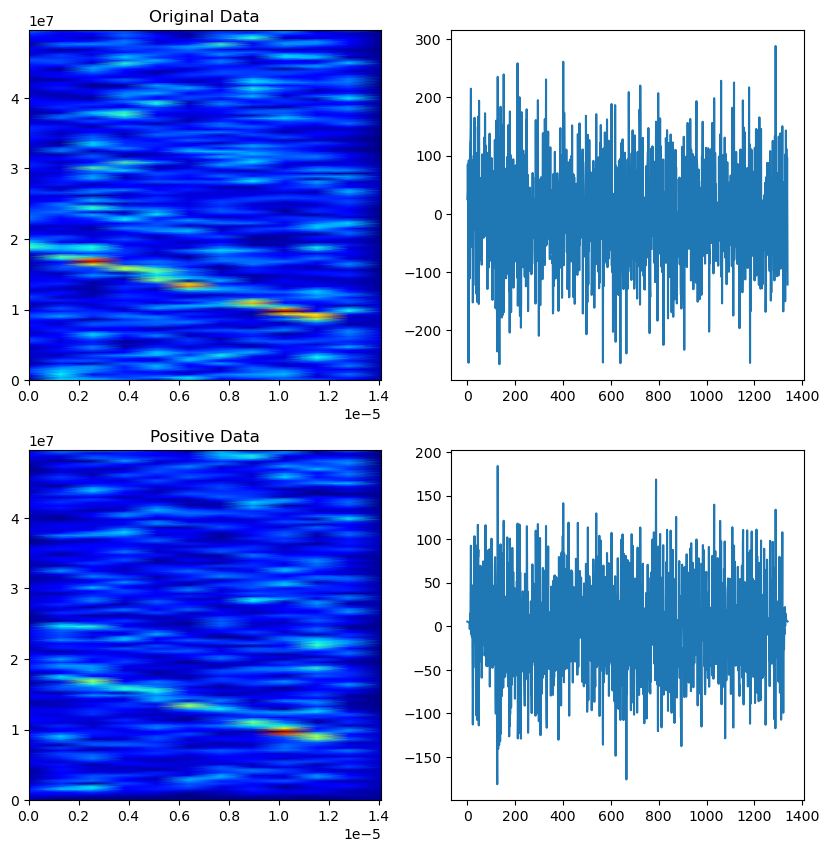

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from models._config import *
from models.LSTM import BiLSTM
from models.UNET import UNet, U2Net
from ex_models.LRP import LRP

# 데이터 로드
def numpy_load(dir, file):
    file = os.path.join(dir, file)
    return np.load(file, allow_pickle=True)


test_dir = 'dataset/lpi_testset/'
save_dir = 'ckpts/batch_/All_train_class_dB'


data_batch = numpy_load(save_dir, 'data_batch.npz')
labels_batch = numpy_load(save_dir, 'labels_batch.npz')
relevance_batch = numpy_load(save_dir, 'relevance_batch.npz')

data_dict = {key: torch.from_numpy(data_batch[key]) for key in data_batch}
labels_dict = {key: torch.from_numpy(labels_batch[key]) for key in labels_batch}
relevance_dict = {key: torch.from_numpy(relevance_batch[key]) for key in relevance_batch}
lengths_batch = numpy_load(save_dir, 'lengths_batch.npy')
snrs_batch = numpy_load(save_dir, 'snr_batch.npy')
idx_batch = numpy_load(save_dir, 'idx_batch.npy')

fs = 100e6
epochs = 500

losses = []
best_loss = float('inf')
best_state = None

CEloss = nn.CrossEntropyLoss()
model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms))
model = nn.DataParallel(model).cuda()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

from sklearn.utils import shuffle
import matplotlib.pyplot as plt
for epoch in range(epochs):
    total_loss = 0.0
    progress = tqdm(range(len(data_dict)), total=len(data_dict), desc=f'Epoch {epoch+1}/{epochs}')
    for batch in progress:
        key = f'arr_{batch}'
        data_batch, label_batch, relevance_batch = data_dict[key], labels_dict[key], relevance_dict[key]
        length_batch, snr_batch = lengths_batch[batch], snrs_batch[batch]
        
        pos_data_batch = np.transpose(
            np.array([[d.real, d.imag] for d in [
                highpass_filter(comp(np.where(r[:, 0] > 0, d[:, 0], 0), 
                                    np.where(r[:, 1] > 0, d[:, 1], 0)), 1e6, fs) 
                for d, r in zip(data_batch, relevance_batch)
            ]]), (0, 2, 1)
        )
        
        shuffle = False
        batch_sample = shuffle(list(zip(data_batch, pos_data_batch, length_batch))) if shuffle else zip(data_batch, pos_data_batch, length_batch)
        for data, pos, l in batch_sample:
            fig, axs = plt.subplots(2, 2, figsize=(10, 10))
            data = data[:l]
            pos =   pos[:l]
            f, a, fft = fft_transform(data[:, 0], data[:, 1], fs)
            f, t, Zxx = stft_transform(data[:, 0], data[:, 1], fs)
            
            axs[0, 0].pcolormesh(t, f[:len(f)//2], Zxx[:len(f)//2], shading='gouraud', cmap='jet')
            axs[0, 0].set_title('Original Data')
            axs[0, 1].plot(fft)
            
            ff, aa, ffft = fft_transform(pos[:, 0], pos[:, 1], fs)
            ff, tt, tZxx = stft_transform(pos[:, 0], pos[:, 1], fs)
            axs[1, 0].pcolormesh(tt, ff[:len(ff)//2], tZxx[:len(ff)//2], shading='gouraud', cmap='jet')
            axs[1, 0].set_title('Positive Data')
            axs[1, 1].plot(ffft)
            

            break

        break
    break
#         pos_data_batch = torch.stack([torch.tensor(data.copy(), dtype=torch.float32) for data in pos_data_batch]).cuda()
#         pos_data_batch = rnn_utils.pad_sequence(pos_data_batch, batch_first=True)
        
#         length_batch = torch.tensor(length_batch, dtype=torch.int64).cpu()
        
        
#         output = model(pos_data_batch, length_batch)
#         loss = CEloss(output, label_batch.cuda())
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()

#         total_loss += loss.item()

#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         progress.set_postfix({'Batch': f'{batch+1}/{len(data_dict)}', 'Loss': f'{loss.item():.4f}'})

#     avg_loss = total_loss / len(data_dict)
#     losses.append(avg_loss)
#     print(f'Epoch {epoch+1}/{epochs} Loss: {avg_loss:.4f}')
    
#     if avg_loss < best_loss:
#         best_loss = avg_loss
#         best_state = model.state_dict()
#         torch.save(best_state, f'./ckpts/pwnNoisy/BiLSTM_R>0_best_{best_loss:.4f}.pth')
#         if best_loss < 0.002:
#             break
#     torch.cuda.empty_cache()
# torch.save(model.state_dict(), f'./ckpts/pwnNoisy/BiLSTM_R>0_final_{avg_loss:.4f}.pth')


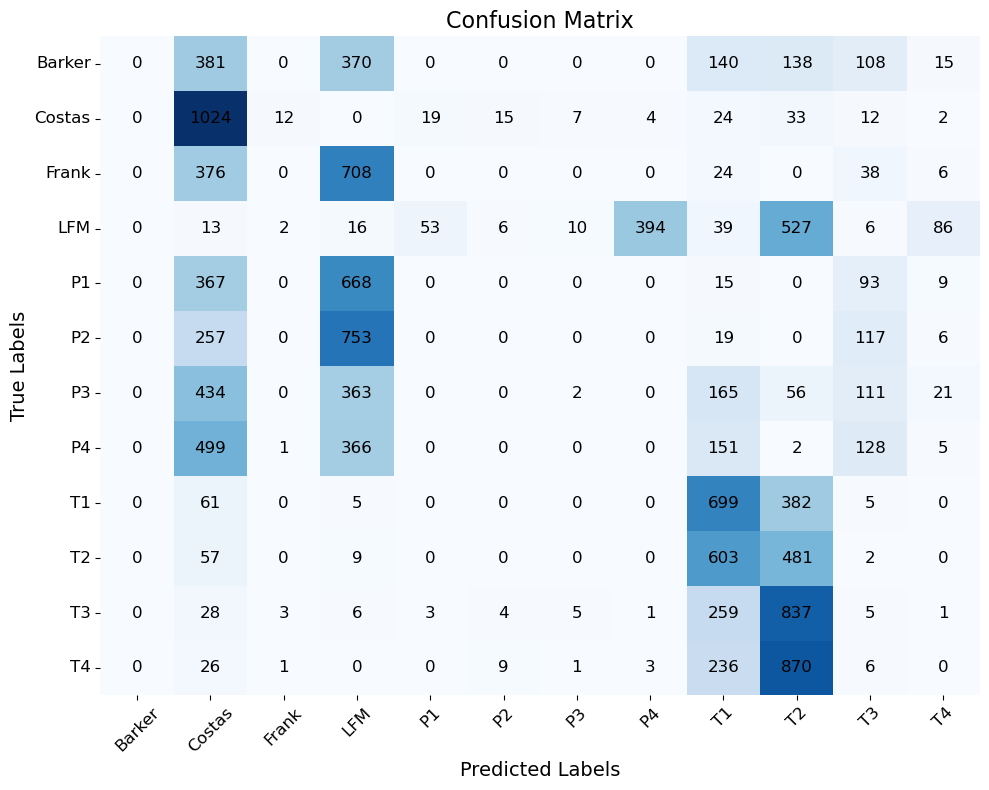

/home/kiwan/TSC_XAI/models/_config.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = [torch.tensor(seq, dtype=torch.float32) for seq in data]


OutOfMemoryError: CUDA out of memory. Tried to allocate 17.04 GiB. GPU 0 has a total capacty of 9.77 GiB of which 7.09 GiB is free. Including non-PyTorch memory, this process has 2.66 GiB memory in use. Of the allocated memory 1.06 GiB is allocated by PyTorch, and 449.68 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [10]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from dataset.LPIdataset import LPIDataset
from models._config import *
from torch.utils.data import DataLoader
from models.LSTM import BiLSTM, BiLSTM_CA
from models.CNN import UNet

def model_accuracy_by_snr(model, dataloader, classes):
    model.eval()
    snr_accuracy = {}
    all_preds = []
    all_labels = []
    snr_levels = []

    with torch.no_grad():
        for data_batch, labels_batch, lengths_batch, snr, idx in dataloader:
            data_batch = data_batch.cuda()
            labels_batch = labels_batch.cuda()

            outputs = model(data_batch, lengths_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
            snr_levels.extend(snr)

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    snr_levels = np.array(snr_levels)

    # Calculate accuracy for each SNR level
    unique_snrs = np.unique(snr_levels)
    for snr_level in unique_snrs:
        indices = snr_levels == snr_level
        snr_preds = all_preds[indices]
        snr_labels = all_labels[indices]

        accuracy = accuracy_score(snr_labels, snr_preds)
        snr_accuracy[snr_level] = accuracy
        print(f"SNR: {snr_level} dB, Accuracy: {accuracy:.4f}")

    # Overall accuracy
    overall_accuracy = accuracy_score(all_labels, all_preds)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")

    return snr_accuracy


def model_confusion(model, dataloader, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data_batch, labels_batch, lengths_batch, snr, idx in dataloader:
            data_batch = data_batch.cuda()
            labels_batch = labels_batch.cuda()

            outputs = model(data_batch, lengths_batch)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    conf_matrix = confusion_matrix(all_labels, all_preds, labels=range(len(classes)))
    conf_matrix = conf_matrix.astype(int)

    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(conf_matrix, annot=False, cmap="Blues", 
                     xticklabels=classes, yticklabels=classes, cbar=False)

    # Add text annotations manually
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            text = str(conf_matrix[i, j])
            ax.text(j + 0.5, i + 0.5, text, ha="center", va="center", color="black", fontsize=12)

    plt.xlabel('Predicted Labels', fontsize=14)
    plt.ylabel('True Labels', fontsize=14)
    plt.title('Confusion Matrix', fontsize=16)
    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.show()


ckpt = 'ckpts/pwnNoisy/BiLSTM_best_0.0638087096589583.pth'
ckpt_ca = 'ckpts/pwnNoisy/BiLSTM_CA2_best_0.2195.pth'
ckpt_cnn = 'ckpts/pwnNoisy/UNET_best_0.0165.pth'


test_dir = 'dataset/lpi_testset_100e6_1.5'
test_stft = test_dir + '_STFT'

dataset = LPIDataset(test_dir, waveforms, data_type=datatypes[-1], model_type=modeltypes[0])
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate)

# dataset_stft = LPIDataset(test_stft, waveforms, model_type='UNet')
# dataloader_stft = DataLoader(dataset_stft, batch_size=32, shuffle=True, collate_fn=collate)

def load_model(ckpt, model):
    state_dict = {}
    for k, v in torch.load(ckpt).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    return model

model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms)).cuda()
model_ca = BiLSTM_CA(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms), factor=1).cuda()
model_unet = UNet(in_channels=1, out_channels=len(waveforms)).cuda()

model = load_model(ckpt, model)
model_ca = load_model(ckpt_ca, model_ca)
# model_unet = load_model(ckpt_cnn, model_unet)

model_confusion(model, dataloader, waveforms)
model_confusion(model_ca, dataloader, waveforms)
# model_confusion(model_unet, dataloader_stft, waveforms)
# snr_accuracies = model_accuracy_by_snr(model_unet, dataloader, waveforms)


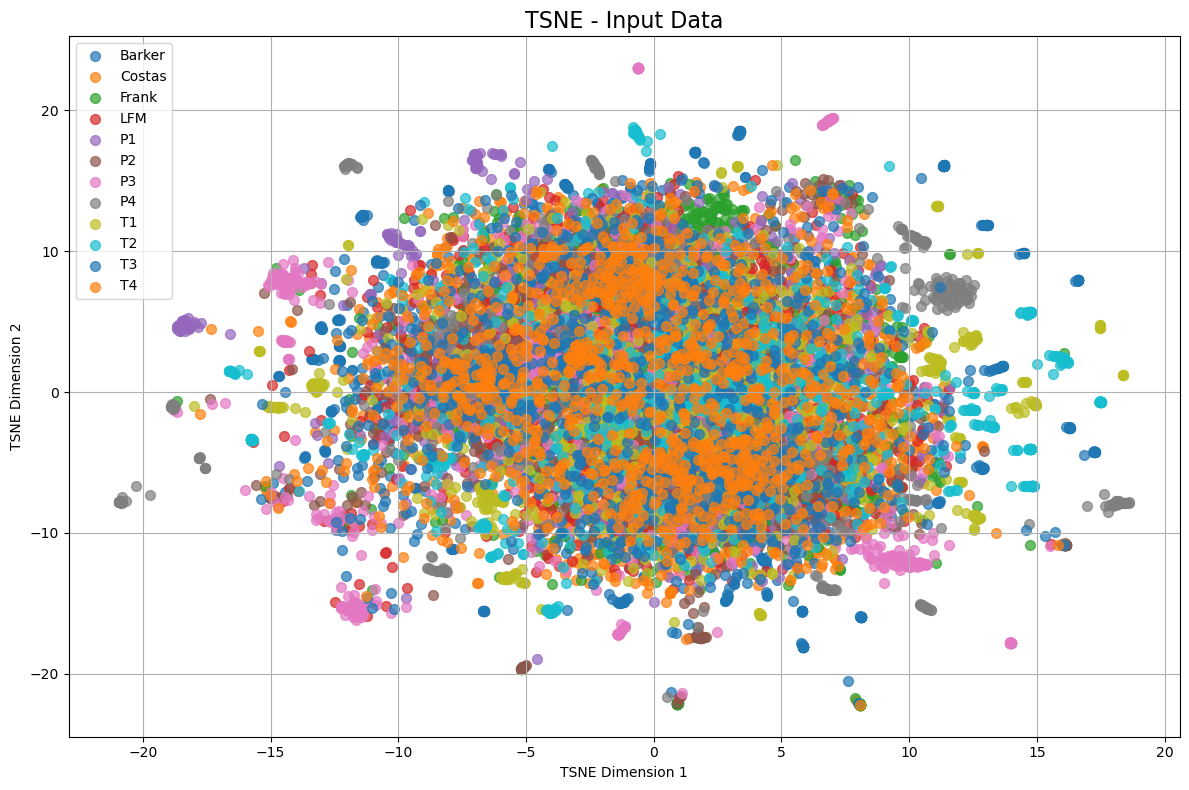

/home/kiwan/TSC_XAI/models/_config.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = [torch.tensor(seq, dtype=torch.float32) for seq in data]


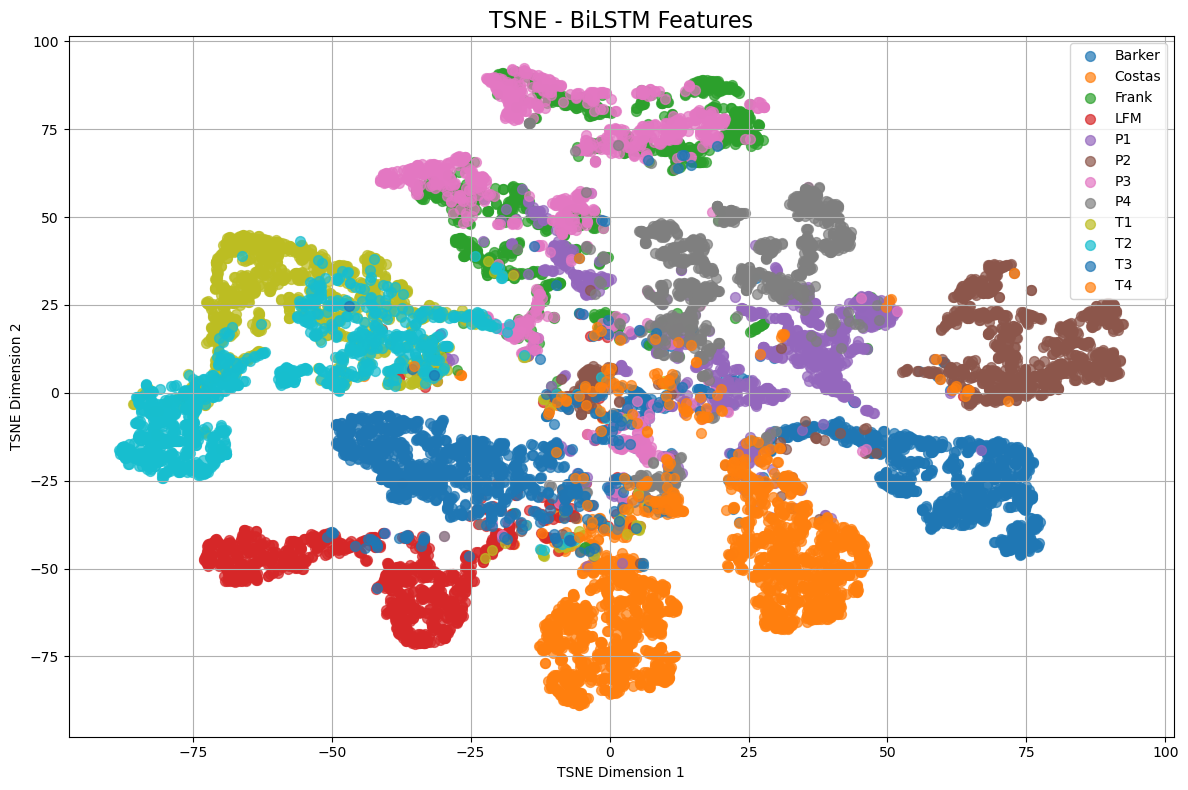

/home/kiwan/TSC_XAI/models/_config.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = [torch.tensor(seq, dtype=torch.float32) for seq in data]


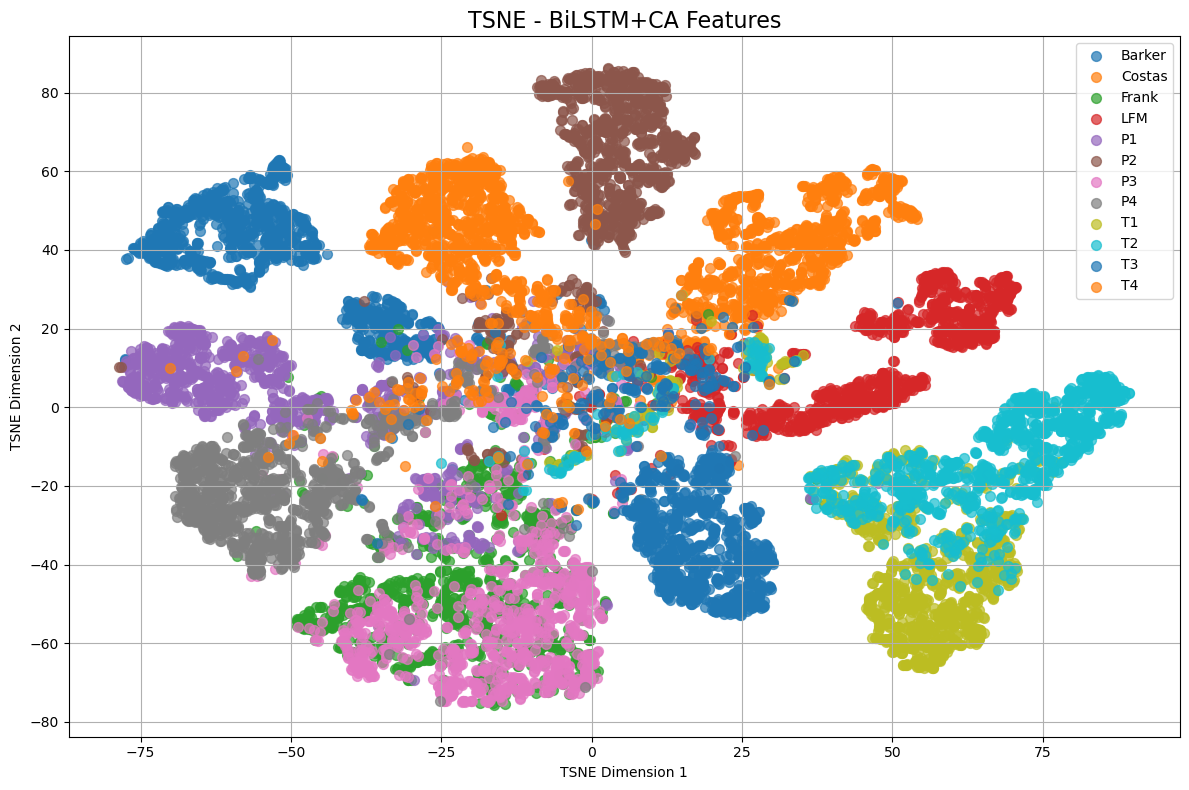

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import torch
from dataset.LPIdataset import LPIDataset
from models._config import *
from torch.utils.data import DataLoader
from models.LSTM import BiLSTM, BiLSTM_CA
from models.CNN import UNet

def extract_features(model, dataloader, raw_input=False):
    """Extracts features from the model's intermediate outputs or input data."""
    if not raw_input:
        model.eval()
    features = []
    labels = []

    max_length = 0  # 최댓값 계산용
    with torch.no_grad():
        for data_batch, labels_batch, lengths_batch, snr, idx in dataloader:
            if raw_input:  # 원본 데이터를 사용
                features.extend(data_batch.cpu().numpy())
            else:  # 모델 출력을 사용
                data_batch = data_batch.cuda()
                outputs = model(data_batch, lengths_batch)
                features.extend(outputs.cpu().numpy())
            
            labels.extend(labels_batch.cpu().numpy())
            max_length = max(max_length, max(data.shape[0] for data in data_batch))  # 최장 길이 계산
    
    # 모든 데이터를 같은 길이로 패딩
    padded_features = [np.pad(f, (0, max_length - f.shape[0]), mode='constant') if len(f.shape) == 1 else np.pad(f, ((0, max_length - f.shape[0]), (0, 0)), mode='constant') for f in features]
    features = np.stack(padded_features)
    labels = np.array(labels)

    return features, labels




def visualize_tsne(features, labels, classes, title="TSNE Visualization"):
    """Performs TSNE on the features and visualizes them."""
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
    tsne_results = tsne.fit_transform(features)

    plt.figure(figsize=(12, 8))
    for class_idx, class_name in enumerate(classes):
        class_mask = labels == class_idx
        plt.scatter(tsne_results[class_mask, 0], tsne_results[class_mask, 1], label=class_name, alpha=0.7, s=50)

    plt.title(title, fontsize=16)
    plt.legend(fontsize=10)
    plt.xlabel("TSNE Dimension 1")
    plt.ylabel("TSNE Dimension 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def load_model(ckpt, model):
    state_dict = {}
    for k, v in torch.load(ckpt).items():
        nk = k.replace('module.', '')
        state_dict[nk] = v
    model.load_state_dict(state_dict)
    model.eval()
    return model
ckpt = 'ckpts/pwnNoisy/BiLSTM_best_0.0638087096589583.pth'
ckpt_ca = 'ckpts/pwnNoisy/BiLSTM_CA2_best_0.2195.pth'
ckpt_cnn = 'ckpts/pwnNoisy/UNET_best_0.0165.pth'


test_dir = 'dataset/lpi_testset'#_1e6_1.5'

dataset = LPIDataset(test_dir, waveforms, data_type=datatypes[-1], model_type=modeltypes[0])
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate)

model = BiLSTM(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms)).cuda()
model_ca = BiLSTM_CA(input_size=2, hidden_size=128, num_layers=2, num_classes=len(waveforms), factor=100).cuda()

model = load_model(ckpt, model)
model_ca = load_model(ckpt_ca, model_ca)

# test_stft = test_dir + '_STFT'
# dataset_stft = LPIDataset(test_stft, waveforms, model_type='UNet')
# model_unet = UNet(in_channels=1, out_channels=len(waveforms)).cuda()
# model_unet = load_model(ckpt_cnn, model_unet)

# Example Usage
# TSNE for input dataset
input_features, input_labels = extract_features(None, dataloader=dataloader, raw_input=True)  # Raw input 처리
visualize_tsne(input_features.reshape(len(input_features), -1), input_labels, waveforms, title="TSNE - Input Data")


# TSNE for BiLSTM model features
bilstm_features, bilstm_labels = extract_features(model, dataloader)
visualize_tsne(bilstm_features, bilstm_labels, waveforms, title="TSNE - BiLSTM Features")

# TSNE for BiLSTM+CA model features
bilstm_ca_features, bilstm_ca_labels = extract_features(model_ca, dataloader)
visualize_tsne(bilstm_ca_features, bilstm_ca_labels, waveforms, title="TSNE - BiLSTM+CA Features")

# Uncomment below for UNet if needed
# unet_features, unet_labels = extract_features(model_unet, dataloader_stft)
# visualize_tsne(unet_features.reshape(len(unet_features), -1), unet_labels, waveforms, title="TSNE - UNet Features")


In [ ]:
import numpy as np
"""
SNR: -16 dB, Accuracy: 0.4375
SNR: -14 dB, Accuracy: 0.6348
SNR: -12 dB, Accuracy: 0.8346
SNR: -10 dB, Accuracy: 0.7480
SNR: -8 dB, Accuracy: 0.8822
SNR: -6 dB, Accuracy: 0.9030
SNR: -4 dB, Accuracy: 0.9466
SNR: -2 dB, Accuracy: 0.9681
SNR: 0 dB, Accuracy: 0.9466
Overall Accuracy: 0.8113

"""

conf_matrix = np.array([
    [1109, 3, 5, 4, 6, 4, 0, 3, 0, 2, 2, 14],
    [0, 1072, 0, 12, 6, 1, 0, 7, 2, 12, 18, 22],
    [5, 3, 593, 3, 76, 2, 3, 5, 3, 5, 3, 5],
    [0, 7, 1, 1091, 1, 0, 4, 5, 1, 5, 31, 6],
    [23, 3, 9, 2, 742, 5, 68, 133, 2, 5, 11, 149],
    [6, 2, 4, 5, 21, 1056, 0, 2, 0, 5, 3, 48],
    [19, 2, 452, 3, 26, 0, 599, 25, 1, 0, 9, 16],
    [21, 3, 12, 8, 15, 0, 17, 1023, 0, 1, 4, 48],
    [0, 17, 0, 22, 4, 1, 2, 0, 861, 239, 1, 5],
    [0, 2, 2, 5, 11, 1, 6, 0, 120, 1002, 1, 2],
    [0, 12, 6, 54, 3, 2, 10, 13, 0, 6, 1028, 18],
    [2, 12, 4, 2, 23, 3, 0, 18, 0, 2, 5, 1081]
])

# 대각선 합 (정확히 분류된 샘플)
correct = np.trace(conf_matrix)

# 전체 샘플 수
total = np.sum(conf_matrix)

# 정확도 계산
accuracy = correct / total

print(f"정확히 분류된 샘플 수: {correct}")
print(f"전체 샘플 수: {total}")
print(f"정확도: {accuracy:.4f}")


정확히 분류된 샘플 수: 11257
전체 샘플 수: 13378
정확도: 0.8415
